In [1]:
import torch, torchvision
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch.nn.functional as F

In [2]:
!pip install segmentation-models-pytorch -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 8.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 6.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 549.1/549.1 kB 26.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 20.2 MB/s eta 0:00:00


In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import torch
import torch.nn.functional as F


class DoubleConv(torch.nn.Module):
    def __init__(self, inputChannels, outputChannels, midChannels=None):
        super().__init__()
        
        midChannels = outputChannels if midChannels==None else midChannels

        self.conv1 = torch.nn.Conv2d(inputChannels, midChannels, 3, padding=1)
        self.batchNorm1 = torch.nn.BatchNorm2d(midChannels)
        self.relu1 = torch.nn.ReLU()
        self.conv2 = torch.nn.Conv2d(midChannels, outputChannels, 3, padding=1)
        self.batchNorm2 = torch.nn.BatchNorm2d(outputChannels)
        self.relu2 = torch.nn.ReLU()
    
    def forward(self, x):
        x = self.relu1(self.batchNorm1(self.conv1(x)))
        x = self.relu2(self.batchNorm2(self.conv2(x)))
        return x


class Down(torch.nn.Module):
    def __init__(self, inputChannels, outputChannels):
        super().__init__()
        self.doubleConv = DoubleConv(inputChannels, outputChannels)
        self.maxPool = torch.nn.MaxPool2d((2,2))
        
    def forward(self,x):
        skip = self.doubleConv(x)
        down_sampled = F.max_pool2d(skip, (2,2))
        return skip, down_sampled


class Up(torch.nn.Module):
    def __init__(self, inputChannels, outputChannels):
        super().__init__()

        self.decode = torch.nn.ConvTranspose2d(inputChannels-outputChannels, inputChannels-outputChannels, kernel_size=2, stride=2)
        self.doubleConv = DoubleConv(inputChannels, outputChannels)

    def crop(self, layer, target_size):
        _, _, layer_height, layer_width = layer.size()
        diff_y = (layer_height - target_size[0]) // 2
        diff_x = (layer_width - target_size[1]) // 2
        return layer[
            :, :, diff_y : (diff_y + target_size[0]), diff_x : (diff_x + target_size[1])
        ]

    def forward(self, down_sampled, skip_input):
        up_sampled = self.decode(down_sampled)
        cropped_skip = self.crop(skip_input, up_sampled.shape[2:])
        x = torch.cat((up_sampled, cropped_skip), dim=1)
        return self.doubleConv(x)


class UNet(torch.nn.Module):
    def __init__(self,inputChannels, outputChannels, midChannels=None):
        super().__init__()
    

        self.down1 = Down(inputChannels, 64)
        self.down2 = Down(64, 128)
        self.down3 = Down(128, 256)
        self.down4 = Down(256, 512)
        
        self.doubleConv = DoubleConv(512, 1024)

        self.up1 = Up(512 + 1024, 512)
        self.up2 = Up(256 + 512, 256)
        self.up3 = Up(128 + 256, 128)
        self.up4 = Up(64 + 128, 64)

        self.lastConv = torch.nn.Conv2d(64, outputChannels, kernel_size=3, padding=1)


    def forward(self, x):
        skip1, x = self.down1(x)
        skip2, x = self.down2(x)
        skip3, x = self.down3(x)
        skip4, x = self.down4(x)

        x = self.doubleConv(x)

        x = self.up1(x, skip4)
        x = self.up2(x, skip3)
        x = self.up3(x, skip2)
        x = self.up4(x, skip1)
        
        return self.lastConv(x)


base_model = UNet(1, 1).to(device)

In [8]:
import torch
from torchvision import models

class UNet_VGG_4layer(torch.nn.Module):
    def __init__(self,input_channels, output_channels):
        super().__init__()

        # load the model
        self.vgg16 = models.vgg16(weights='VGG16_Weights.IMAGENET1K_V1')
        self.vgg16.features[0] = torch.nn.Conv2d(input_channels, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        
        self.maxPool = torch.nn.MaxPool2d((2,2))

        self.doubleConv = DoubleConv(512, 1024)
        
        self.down1 = self.vgg16.features[:4] # 64 channel
        self.down2 = self.vgg16.features[5:9] # 128 channel
        self.down3 = self.vgg16.features[10:16] # 256 channel
        self.down4 = self.vgg16.features[17:23] # 512 channel

        self.up1 = Up(512 + 1024, 512)
        self.up2 = Up(256 + 512, 256)
        self.up3 = Up(128 + 256, 128)
        self.up4 = Up(64 + 128, 64)

        self.lastConv = torch.nn.Conv2d(64, output_channels, kernel_size=3, padding=1)

    def forward(self, x):

        skip1 = self.down1(x)
        x = self.maxPool(skip1)
        #print(f"skip1 {skip1.shape}, x {x.shape}")

        skip2 = self.down2(x)
        x = self.maxPool(skip2)
        #print(f"skip2 {skip2.shape}, x {x.shape}")

        skip3 = self.down3(x)
        x = self.maxPool(skip3)
        #print(f"skip3 {skip3.shape}, x {x.shape}")

        skip4 = self.down4(x)
        x = self.maxPool(skip4)
        #print(f"skip4 {skip4.shape}, x {x.shape}")


        x = self.doubleConv(x)

        x = self.up1(x, skip4)
        x = self.up2(x, skip3)
        x = self.up3(x, skip2)
        x = self.up4(x, skip1)
        
        return self.lastConv(x)

model_4layer = UNet_VGG_4layer(1, 1).to(device)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:05<00:00, 101MB/s]


In [9]:
import torch
import torch.nn as nn
from torchvision import models

class UNet_5layer(torch.nn.Module):
    def __init__(self, input_channels, output_channels):
        super().__init__()

        # Load a pre-trained VGG16 model
        self.vgg16 = models.vgg16(weights='VGG16_Weights.IMAGENET1K_V1')
        self.vgg16.features[0] = torch.nn.Conv2d(input_channels, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        
        self.relu = torch.nn.ReLU()
        
        self.maxPool = torch.nn.MaxPool2d((2,2))

        self.down1 = self.vgg16.features[:4] # 64 channel
        self.down2 = self.vgg16.features[5:9] # 128 channel
        self.down3 = self.vgg16.features[10:16] # 256 channel
        self.down4 = self.vgg16.features[17:23] # 512 channel
        self.down5 = nn.Sequential(*list(self.vgg16.features[24:30]), nn.Conv2d(512, 1024, kernel_size=3, padding=1))

        self.doubleConv = DoubleConv(1024, 1024)

        self.up1 = Up(1024 + 1024, 1024)
        self.up2 = Up(512 + 1024, 512)
        self.up3 = Up(256 + 512, 256)
        self.up4 = Up(128 + 256, 128)
        self.up5 = Up(64 + 128, 64)

        self.lastConv = torch.nn.Conv2d(64, output_channels, kernel_size=3, padding=1)

    def forward(self, x):

      skip1 = self.down1(x)
      x = self.maxPool(skip1)
      #print(f"skip1 {skip1.shape}, x {x.shape}")

      skip2 = self.down2(x)
      x = self.maxPool(skip2)
      #print(f"skip2 {skip2.shape}, x {x.shape}")

      skip3 = self.down3(x)
      x = self.maxPool(skip3)
      #print(f"skip3 {skip3.shape}, x {x.shape}")

      skip4 = self.down4(x)
      x = self.maxPool(skip4)
      #print(f"skip4 {skip4.shape}, x {x.shape}")

      skip5 = self.down5(x)
      x = self.maxPool(skip5)
      #print(f"skip5 {skip5.shape}, x {x.shape}")

      x = self.doubleConv(x)
      
      
      x = self.up1(x, skip5)
      x = self.up2(x, skip4)
      x = self.up3(x, skip3)
      x = self.up4(x, skip2)
      x = self.up5(x, skip1)
        
      return self.lastConv(x)

model_5layer = UNet_5layer(1, 1).to(device)

In [10]:
from pathlib import Path

from torch.utils.data import Dataset
import torchvision.transforms.functional
from PIL import Image


class AstrocyteDataset(Dataset):
  def __init__(self, train_dir: Path, mask_dir: Path):
    self.train_img = {p.stem: p for p in train_dir.iterdir()}
    self.mask_img = {p.stem: p for p in mask_dir.iterdir()}

    self.ids = list(self.train_img.keys())

    self.transforms = torchvision.transforms.Compose([
            torchvision.transforms.ToTensor()
        ])

  def __getitem__(self, index):
    id_ = self.ids[index]
    
    image = Image.open(self.train_img[id_])
    image = self.transforms(image)

    # Load mask
    mask = Image.open(self.mask_img[id_])
    mask = self.transforms(mask)

    # Normalize
    mask = mask / mask.max()

    return image, mask

  def __len__(self):
    return len(self.ids)

dataset_astrocyte = AstrocyteDataset(train_dir = Path("/content/drive/MyDrive/Star/astrocyte_data/train"), mask_dir=Path("/content/drive/MyDrive/Star/astrocyte_data/train_label"))

In [11]:
image, mask = dataset_astrocyte[0]
print(image.shape, mask.shape, len(dataset_astrocyte))

torch.Size([1, 256, 256]) torch.Size([1, 256, 256]) 23


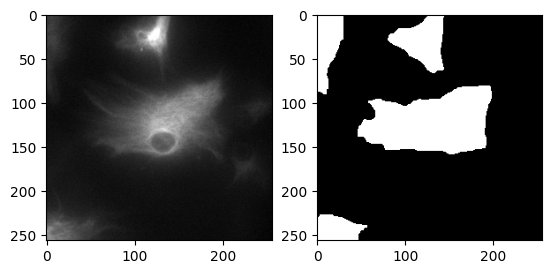

In [14]:
plt.subplot(1,2,1)
plt.imshow(image.permute(1,2,0), cmap="gray")
plt.subplot(1,2,2)
plt.imshow(mask.permute(1,2,0), cmap="gray")

In [16]:
train = torch.utils.data.DataLoader(dataset_astrocyte, batch_size=1, shuffle=False) # Took the batch_size as 1 because we have a small dataset

valsize = int(len(train)*0.2)  # Reserve %20 for validation
trainsize = len(train) - valsize  # Reserve %80 for train

print(f"Validation size is :{valsize}, Training size is :{trainsize}")
trainset, valset = torch.utils.data.random_split(train, [trainsize, valsize])

Validation size is :4, Training size is :19


In [17]:
from segmentation_models_pytorch.losses import FocalLoss, DiceLoss

optimizer = torch.optim.Adam(base_model.parameters(), lr=1e-4, weight_decay=1e-5) # weight_decay=1e-5 for L2 regularization
loss_fn = torch.nn.BCEWithLogitsLoss() # Binary segmentation

In [18]:
def accuracy_score(y_true, y_pred, threshold=0.5):
    y_pred = (y_pred > threshold).float()
    correct = (y_pred == y_true).float().sum()
    total = y_true.numel()
    accuracy = correct / total
    return accuracy.item()

In [19]:
def plot_loss_acc(loss_list, acc_list):
  plt.subplot(2,1,1)
  plt.plot([x for x in range(len(loss_list))], loss_list, "b-")
  plt.title("Loss over epochs")
  plt.annotate(f"{min(loss_list):.3f}", xy=(0.9, 0.9), xycoords='axes fraction', 
               horizontalalignment='right', verticalalignment='top')

  plt.subplot(2,1,2)
  plt.plot([x for x in range(len(acc_list))], acc_list, "b-")
  plt.title("Accuracy over epochs")
  plt.annotate(f"{max(acc_list):.3f}", xy=(0.9, 0.1), xycoords='axes fraction', 
               horizontalalignment='right', verticalalignment='top')

In [20]:
from tqdm import tqdm


def training(model, loss_fn, optimizer, train_set, val_set, epoch):
  loss_list = []
  acc_list = []
  for epoch in range(epoch):
      model.train()
      epoch_loss = 0
      epoch_accuracy = 0
      for batch in trainset.dataset:
          Xs, ys = batch
          Xs = Xs.to(device)
          ys = ys.to(device)

          model.zero_grad()
          preds = model(Xs)
          loss = loss_fn(preds, ys)
          loss.backward()
          optimizer.step()
          epoch_loss += loss.item()

          # Calculate accuracy
          with torch.no_grad():
              accuracy = accuracy_score(ys, preds)
              epoch_accuracy += accuracy
          
      average_loss = epoch_loss / len(trainset.dataset)
      average_accuracy = epoch_accuracy / len(trainset.dataset)
      print(f"Epoch {epoch+1} average loss: {average_loss:.3f}, average accuracy: {average_accuracy:.3f}", end=" ")

      # loss and accuracy on the validation set
      model.eval()
      val_loss = 0
      val_accuracy = 0
      with torch.no_grad():
          for batch in val_set.dataset:
              Xs, ys = batch
              Xs = Xs.to(device)
              ys = ys.to(device)

              preds = model(Xs)
              loss = loss_fn(preds, ys)
              val_loss += loss.item()

              # Calculate accuracy
              val_accuracy += accuracy_score(ys, preds)
      
      val_average_loss = val_loss / len(val_set.dataset)
      val_average_accuracy = val_accuracy / len(val_set.dataset)
      print(f"average val loss: {val_average_loss:.3f}, average val accuracy: {val_average_accuracy:.3f}")
      loss_list.append(val_average_loss)
      acc_list.append(val_average_accuracy)
    
  return loss_list, acc_list

In [21]:
base_loss_list, base_acc_list= training(base_model, loss_fn, optimizer, train_set=trainset, val_set=valset, epoch=100)

Epoch 1 average loss: 0.475, average accuracy: 0.863 average val loss: 0.519, average val accuracy: 0.812
Epoch 2 average loss: 0.351, average accuracy: 0.881 average val loss: 0.412, average val accuracy: 0.861
Epoch 3 average loss: 0.306, average accuracy: 0.887 average val loss: 0.383, average val accuracy: 0.861
Epoch 4 average loss: 0.274, average accuracy: 0.896 average val loss: 0.285, average val accuracy: 0.886
Epoch 5 average loss: 0.261, average accuracy: 0.901 average val loss: 0.247, average val accuracy: 0.896
Epoch 6 average loss: 0.242, average accuracy: 0.905 average val loss: 0.283, average val accuracy: 0.889
Epoch 7 average loss: 0.223, average accuracy: 0.912 average val loss: 0.222, average val accuracy: 0.907
Epoch 8 average loss: 0.212, average accuracy: 0.914 average val loss: 0.240, average val accuracy: 0.905
Epoch 9 average loss: 0.201, average accuracy: 0.919 average val loss: 0.223, average val accuracy: 0.909
Epoch 10 average loss: 0.182, average accuracy

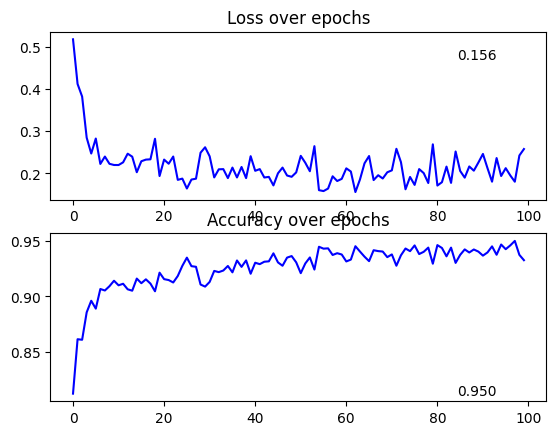

In [22]:
plot_loss_acc(base_loss_list, base_acc_list)

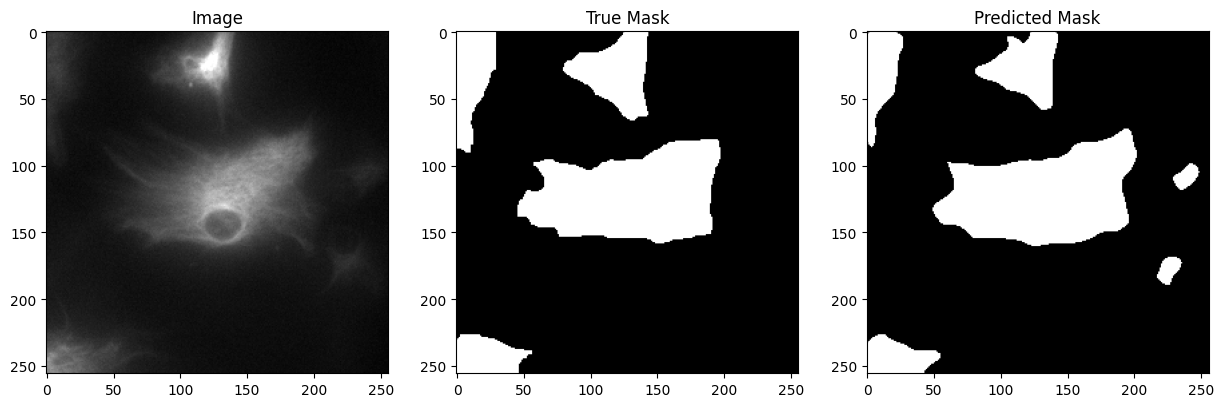

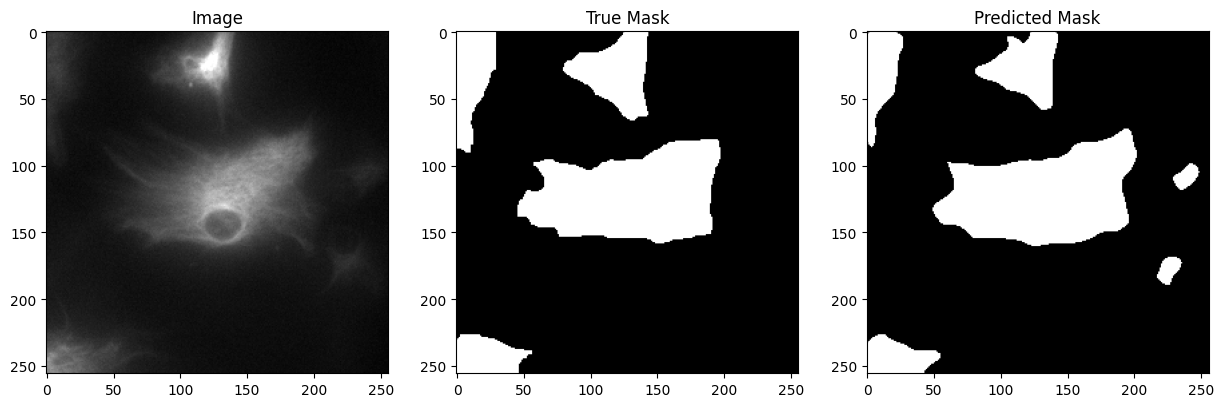

In [25]:
def display_image_mask_prediction(model, image, mask, threshold=0.9):
    image_tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        model.eval()
        pred_mask = model(image_tensor).cpu()
        pred_mask = F.sigmoid(pred_mask)
        pred_mask = (pred_mask > threshold).float()

    image = image.cpu().permute(1, 2, 0).numpy()
    true_mask = mask.cpu().permute(1, 2, 0).numpy()
    pred_mask = pred_mask.squeeze(0).permute(1, 2, 0).numpy()

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap="gray")
    plt.title("Image")

    plt.subplot(1, 3, 2)
    plt.imshow(true_mask, cmap="gray")
    plt.title("True Mask")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask, cmap="gray")
    plt.title("Predicted Mask")

    plt.show()

for batch in valset.dataset:
  for i in range(len(batch)):
    Xs, ys = batch
    Xs = Xs.to(device)
    ys = ys.to(device)
    display_image_mask_prediction(base_model, Xs[i-1], ys[i-1], threshold=0.6)
  break


In [26]:
from segmentation_models_pytorch.losses import FocalLoss, DiceLoss

base_model = UNet(1, 1).to(device) # Called the model to reset weights

optimizer = torch.optim.Adam(base_model.parameters(), lr=1e-4, weight_decay=1e-5) # weight_decay=1e-5 for L2 regularization
loss_fn = DiceLoss("binary")


In [27]:
dice_base_loss_list, dice_base_acc_list= training(base_model, loss_fn, optimizer, train_set=trainset, val_set=valset, epoch=100)

Epoch 1 average loss: 0.492, average accuracy: 0.845 average val loss: 0.583, average val accuracy: 0.831
Epoch 2 average loss: 0.381, average accuracy: 0.855 average val loss: 0.389, average val accuracy: 0.796
Epoch 3 average loss: 0.339, average accuracy: 0.872 average val loss: 0.328, average val accuracy: 0.842
Epoch 4 average loss: 0.304, average accuracy: 0.888 average val loss: 0.297, average val accuracy: 0.883
Epoch 5 average loss: 0.282, average accuracy: 0.893 average val loss: 0.270, average val accuracy: 0.874
Epoch 6 average loss: 0.257, average accuracy: 0.903 average val loss: 0.243, average val accuracy: 0.907
Epoch 7 average loss: 0.234, average accuracy: 0.910 average val loss: 0.236, average val accuracy: 0.888
Epoch 8 average loss: 0.216, average accuracy: 0.918 average val loss: 0.229, average val accuracy: 0.896
Epoch 9 average loss: 0.212, average accuracy: 0.916 average val loss: 0.250, average val accuracy: 0.863
Epoch 10 average loss: 0.197, average accuracy

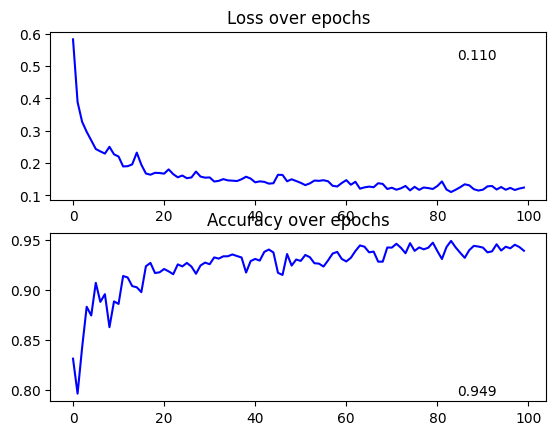

In [28]:
plot_loss_acc(dice_base_loss_list, dice_base_acc_list)

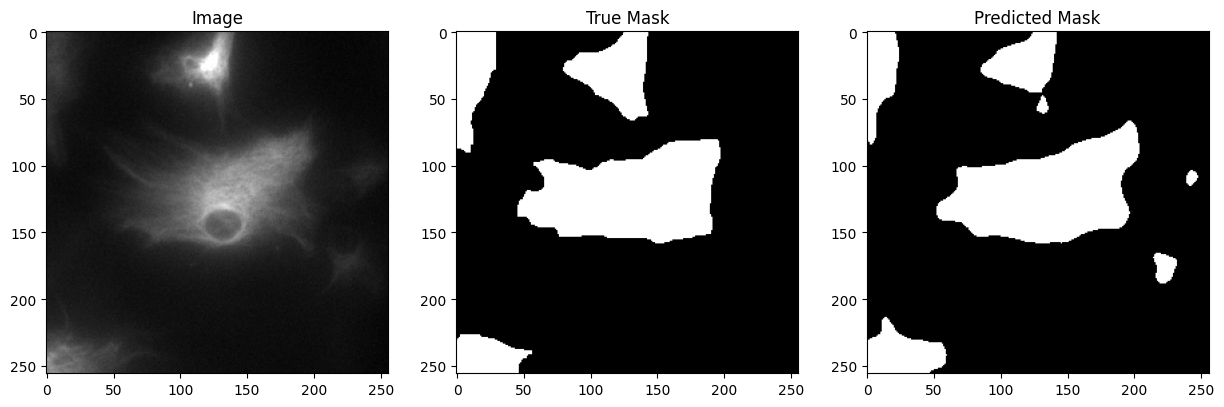

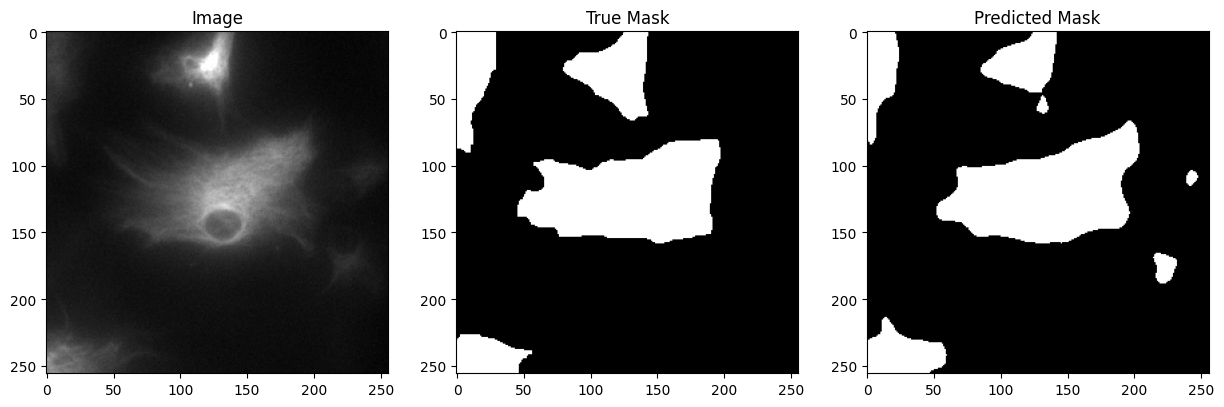

In [29]:
for batch in valset.dataset:
  for i in range(len(batch)):
    Xs, ys = batch
    Xs = Xs.to(device)
    ys = ys.to(device)
    display_image_mask_prediction(base_model, Xs[i-1], ys[i-1], threshold=0.6)
  break

In [30]:
optimizer = torch.optim.Adam(model_4layer.parameters(), lr=1e-4, weight_decay=1e-5) # weight_decay=1e-5 for L2 regularization
loss_fn = DiceLoss("binary")

In [31]:
dice_4_loss_list, dice_4_acc_list= training(model_4layer, loss_fn, optimizer, train_set=trainset, val_set=valset, epoch=100)

Epoch 1 average loss: 0.494, average accuracy: 0.849 average val loss: 0.522, average val accuracy: 0.863
Epoch 2 average loss: 0.398, average accuracy: 0.854 average val loss: 0.390, average val accuracy: 0.794
Epoch 3 average loss: 0.354, average accuracy: 0.869 average val loss: 0.307, average val accuracy: 0.889
Epoch 4 average loss: 0.310, average accuracy: 0.887 average val loss: 0.279, average val accuracy: 0.893
Epoch 5 average loss: 0.277, average accuracy: 0.899 average val loss: 0.269, average val accuracy: 0.875
Epoch 6 average loss: 0.259, average accuracy: 0.901 average val loss: 0.239, average val accuracy: 0.902
Epoch 7 average loss: 0.239, average accuracy: 0.906 average val loss: 0.236, average val accuracy: 0.891
Epoch 8 average loss: 0.215, average accuracy: 0.917 average val loss: 0.200, average val accuracy: 0.911
Epoch 9 average loss: 0.208, average accuracy: 0.918 average val loss: 0.242, average val accuracy: 0.864
Epoch 10 average loss: 0.203, average accuracy

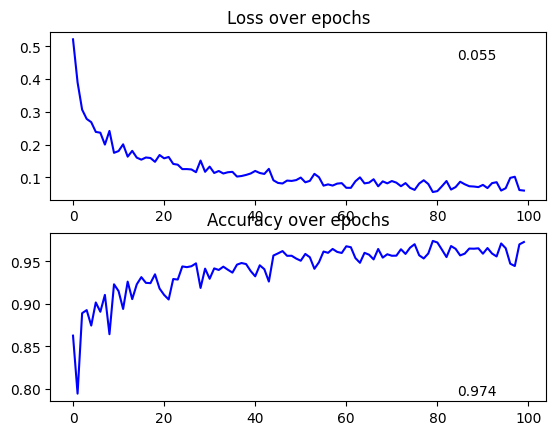

In [32]:
plot_loss_acc(dice_4_loss_list, dice_4_acc_list)

In [33]:
optimizer = torch.optim.Adam(model_5layer.parameters(), lr=1e-4, weight_decay=1e-5) # weight_decay=1e-5 for L2 regularization
loss_fn = DiceLoss("binary")

In [34]:
dice_5_loss_list, dice_5_acc_list= training(model_5layer, loss_fn, optimizer, train_set=trainset, val_set=valset, epoch=100)

Epoch 1 average loss: 0.490, average accuracy: 0.844 average val loss: 0.523, average val accuracy: 0.865
Epoch 2 average loss: 0.380, average accuracy: 0.871 average val loss: 0.354, average val accuracy: 0.878
Epoch 3 average loss: 0.330, average accuracy: 0.880 average val loss: 0.310, average val accuracy: 0.860
Epoch 4 average loss: 0.287, average accuracy: 0.895 average val loss: 0.262, average val accuracy: 0.891
Epoch 5 average loss: 0.254, average accuracy: 0.904 average val loss: 0.239, average val accuracy: 0.909
Epoch 6 average loss: 0.230, average accuracy: 0.911 average val loss: 0.220, average val accuracy: 0.905
Epoch 7 average loss: 0.211, average accuracy: 0.916 average val loss: 0.201, average val accuracy: 0.915
Epoch 8 average loss: 0.185, average accuracy: 0.928 average val loss: 0.192, average val accuracy: 0.920
Epoch 9 average loss: 0.181, average accuracy: 0.927 average val loss: 0.179, average val accuracy: 0.922
Epoch 10 average loss: 0.170, average accuracy

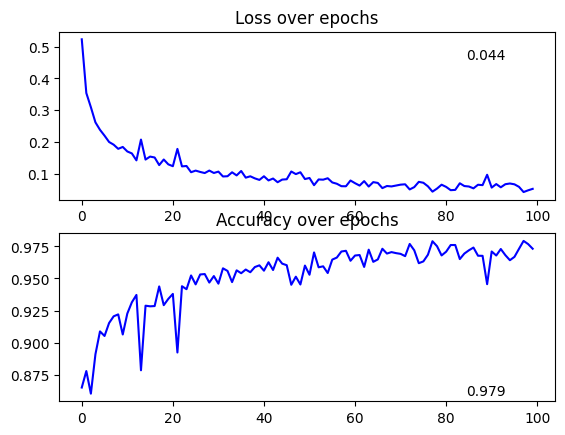

In [35]:
plot_loss_acc(dice_5_loss_list, dice_5_acc_list)

In [36]:
!pip install ternausnet -q

In [ ]:
from ternausnet import models

ternaus = models.UNet16(num_classes=1, pretrained=True, is_deconv=True)
ternaus.conv1[0] = torch.nn.Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
ternaus.to(device)

In [42]:
optimizer = torch.optim.Adam(ternaus.parameters(), lr=1e-4, weight_decay=1e-5) # weight_decay=1e-5 for L2 regularization
loss_fn = DiceLoss("binary")

In [43]:
ternaus_loss_list, ternaus_acc_list= training(ternaus, loss_fn, optimizer, train_set=trainset, val_set=valset, epoch=100)

Epoch 1 average loss: 0.631, average accuracy: 0.725 average val loss: 0.550, average val accuracy: 0.600
Epoch 2 average loss: 0.529, average accuracy: 0.760 average val loss: 0.482, average val accuracy: 0.836
Epoch 3 average loss: 0.335, average accuracy: 0.824 average val loss: 0.253, average val accuracy: 0.859
Epoch 4 average loss: 0.268, average accuracy: 0.840 average val loss: 0.253, average val accuracy: 0.866
Epoch 5 average loss: 0.261, average accuracy: 0.854 average val loss: 0.246, average val accuracy: 0.861
Epoch 6 average loss: 0.247, average accuracy: 0.855 average val loss: 0.232, average val accuracy: 0.857
Epoch 7 average loss: 0.231, average accuracy: 0.865 average val loss: 0.456, average val accuracy: 0.622
Epoch 8 average loss: 0.264, average accuracy: 0.840 average val loss: 0.247, average val accuracy: 0.883
Epoch 9 average loss: 0.230, average accuracy: 0.874 average val loss: 0.214, average val accuracy: 0.880
Epoch 10 average loss: 0.218, average accuracy

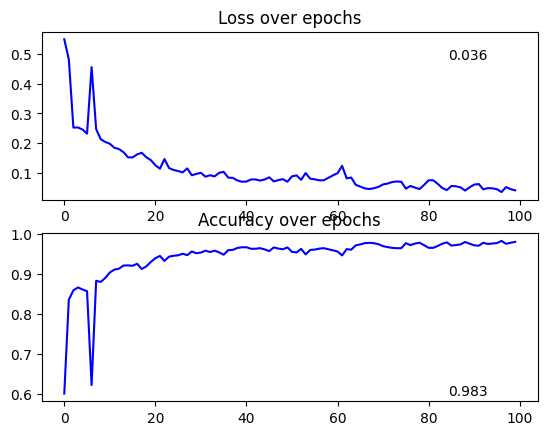

In [44]:
plot_loss_acc(ternaus_loss_list, ternaus_acc_list)

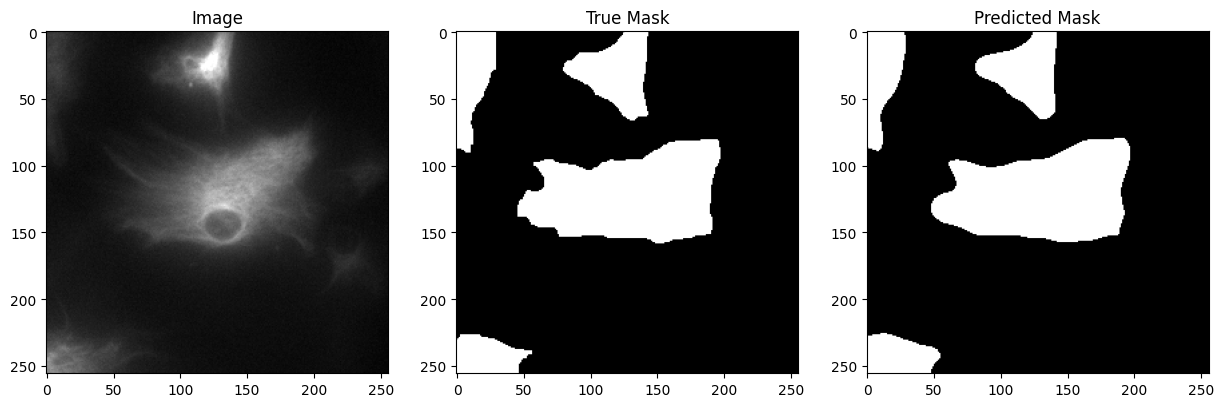

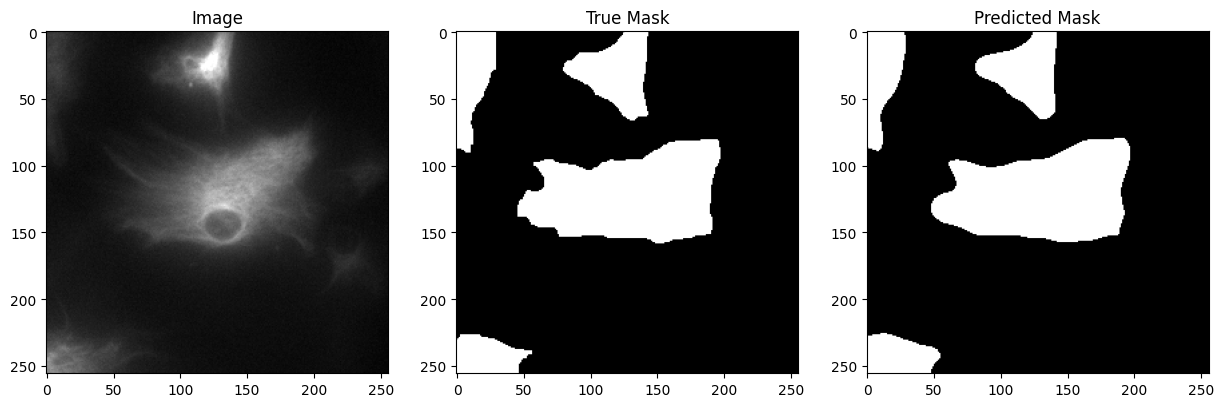

In [45]:
for batch in valset.dataset:
  for i in range(len(batch)):
    Xs, ys = batch
    Xs = Xs.to(device)
    ys = ys.to(device)
    display_image_mask_prediction(ternaus, Xs[i-1], ys[i-1], threshold=0.6)
  break